# 09. Classifiers on dataset C

Trains TF-IDF + SVM, LogReg, MLP and RandomForest to pick the tool from the prompt, and compares
them with Llama 3.2 3B.

- **`pred_svm`** is out of fold: 5-fold cross validation stratified on the tool (seed 42), so every
  row is predicted by an SVM that never saw it.
- **Robustness checks:** a split that keeps similar prompts in the same fold, training on dataset
  C and testing on the 405 Claude-written prompts, and a learning curve.
- **Agreement table:** how often the SVM and Llama are each right or wrong. This is the input for
  the agreement / disagreement NIO models.

In [1]:
import re
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
from sklearn.base import clone
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.cluster import AgglomerativeClustering
from sklearn.model_selection import StratifiedKFold, GroupKFold
from sklearn.metrics import f1_score, confusion_matrix

C = pd.read_csv("cyber_dataset_C.csv").drop(columns=["pred_svm"], errors="ignore")
T = pd.read_csv("cyber_testset_claude405.csv")
X, y = C["prompt"].astype(str), C["tool_ground_truth"].to_numpy()
llama = C["tool_predicted"].to_numpy()

MODELS = {
    "SVM":          SVC(kernel="linear", random_state=42),
    "LogReg":       LogisticRegression(max_iter=1000, random_state=42),
    "MLP":          MLPClassifier(hidden_layer_sizes=(64, 32), max_iter=500, random_state=42),
    "RandomForest": RandomForestClassifier(n_estimators=100, random_state=42),
}
vectorizer = lambda: TfidfVectorizer(ngram_range=(1, 2), max_features=5000)
print(len(C), "rows")

1020 rows


## 1. Out-of-fold predictions

The assertions check that no row is in the training part of the fold that predicts it, and that each row is predicted exactly once.

In [2]:
def out_of_fold(splits):
    oof = {m: np.empty(len(C), dtype=object) for m in MODELS}
    times = np.zeros(len(C), dtype=int)
    for tr, te in splits:
        assert not (set(tr) & set(te))
        vec = vectorizer()
        Xtr, Xte = vec.fit_transform(X.iloc[tr]), vec.transform(X.iloc[te])
        for name, proto in MODELS.items():
            oof[name][te] = clone(proto).fit(Xtr, y[tr]).predict(Xte)
        times[te] += 1
    assert (times == 1).all()
    return oof

oof = out_of_fold(StratifiedKFold(5, shuffle=True, random_state=42).split(X, y))

# similar prompts (sharing at least half their words) go to the same fold
words = X.str.lower().str.replace(r"[^a-z ]", " ", regex=True)
Bm = CountVectorizer(binary=True, token_pattern=r"[a-z]{3,}").fit_transform(words)
inter = (Bm @ Bm.T).toarray(); size = np.asarray(Bm.sum(1)).ravel()
jac = inter / (size[:, None] + size[None, :] - inter + 1e-9); np.fill_diagonal(jac, 0)
groups = AgglomerativeClustering(n_clusters=None, metric="precomputed", linkage="single",
                                 distance_threshold=0.5).fit_predict(1 - jac)
oof_grouped = out_of_fold(GroupKFold(5).split(X, y, groups))
print(f"OK: all predictions are out of fold ({len(set(groups))} similarity groups for the grouped split)")

OK: all predictions are out of fold (1017 similarity groups for the grouped split)


## 2. Llama vs the classifiers

In [3]:
def row(method, protocol, pred):
    pred = np.asarray(pred, dtype=object)
    return {"method": method, "protocol": protocol, "accuracy": (pred == y).mean(),
            "macro F1": f1_score(y, pred, average="macro", labels=sorted(set(y)))}   # Unknown answers count as errors, not as a 12th class

rows = [row("Llama 3.2 3B (all 11 tools)", "no training", llama)]
rows += [row(m, "5-fold", oof[m]) for m in MODELS]
rows += [row(m, "5-fold, similar prompts grouped", oof_grouped[m]) for m in MODELS]
results = pd.DataFrame(rows)
show = results.copy()
show["accuracy"] = (show["accuracy"] * 100).round(1).astype(str) + "%"
show["macro F1"] = show["macro F1"].round(3)
show

,method,protocol,accuracy,macro F1
0,Llama 3.2 3B (all 11 tools),no training,91.2%,0.910
1,SVM,5-fold,91.0%,0.910
2,LogReg,5-fold,90.2%,0.901
3,MLP,5-fold,87.2%,0.871
4,RandomForest,5-fold,80.3%,0.798
5,SVM,"5-fold, similar prompts grouped",90.9%,0.909
6,LogReg,"5-fold, similar prompts grouped",89.1%,0.890
7,MLP,"5-fold, similar prompts grouped",86.6%,0.864
8,RandomForest,"5-fold, similar prompts grouped",79.9%,0.795


## 3. Trained on dataset C, tested on the Claude-written prompts

In [4]:
vec = vectorizer(); XC = vec.fit_transform(X); XT = vec.transform(T["prompt"].astype(str))
yT = T["tool_ground_truth"].to_numpy()
print(f"Llama 3.2 3B on the Claude test set: {(T['tool_predicted'].to_numpy() == yT).mean():.1%}")
for name, proto in MODELS.items():
    print(f"{name:13} trained on C, tested on the Claude set: {(clone(proto).fit(XC, y).predict(XT) == yT).mean():.1%}")

Llama 3.2 3B on the Claude test set: 92.8%


SVM           trained on C, tested on the Claude set: 95.8%
LogReg        trained on C, tested on the Claude set: 95.6%


MLP           trained on C, tested on the Claude set: 95.3%


RandomForest  trained on C, tested on the Claude set: 81.7%


## 4. Learning curve (SVM, 5-fold, training rows subsampled)

In [5]:
for frac in [0.1, 0.25, 0.5, 0.75, 1.0]:
    accs = []
    for tr, te in StratifiedKFold(5, shuffle=True, random_state=42).split(X, y):
        rs = np.random.RandomState(0)
        sub = rs.choice(tr, size=int(len(tr) * frac), replace=False)
        v = vectorizer()
        m = SVC(kernel="linear", random_state=42).fit(v.fit_transform(X.iloc[sub]), y[sub])
        accs.append((m.predict(v.transform(X.iloc[te])) == y[te]).mean())
    print(f"  {frac:>4.0%} of training data ({int(len(tr) * frac):4d} rows): {np.mean(accs):.1%}")

   10% of training data (  81 rows): 28.5%


   25% of training data ( 204 rows): 64.1%


   50% of training data ( 408 rows): 83.6%


   75% of training data ( 612 rows): 88.8%


  100% of training data ( 816 rows): 91.0%


## 5. Where the SVM and Llama agree and disagree

In [6]:
svm_ok, llama_ok = oof["SVM"] == y, llama == y
agree = pd.crosstab(pd.Series(np.where(svm_ok, "SVM right", "SVM wrong"), name=""),
                    pd.Series(np.where(llama_ok, "Llama right", "Llama wrong"), name=""))
print(agree.to_string()); print()
print(f"SVM and Llama pick the same tool on {(oof['SVM'] == llama).mean():.1%} of rows")
print(f"prompts where Llama disagrees with the annotation (for NIO M1): {(~llama_ok).sum()}")
print(f"prompts where the SVM disagrees with the annotation (for NIO M2): {(~svm_ok).sum()}")

           Llama right  Llama wrong
                                   
SVM right          853           75
SVM wrong           77           15

SVM and Llama pick the same tool on 84.2% of rows
prompts where Llama disagrees with the annotation (for NIO M1): 90
prompts where the SVM disagrees with the annotation (for NIO M2): 92


## 6. Confusion matrices

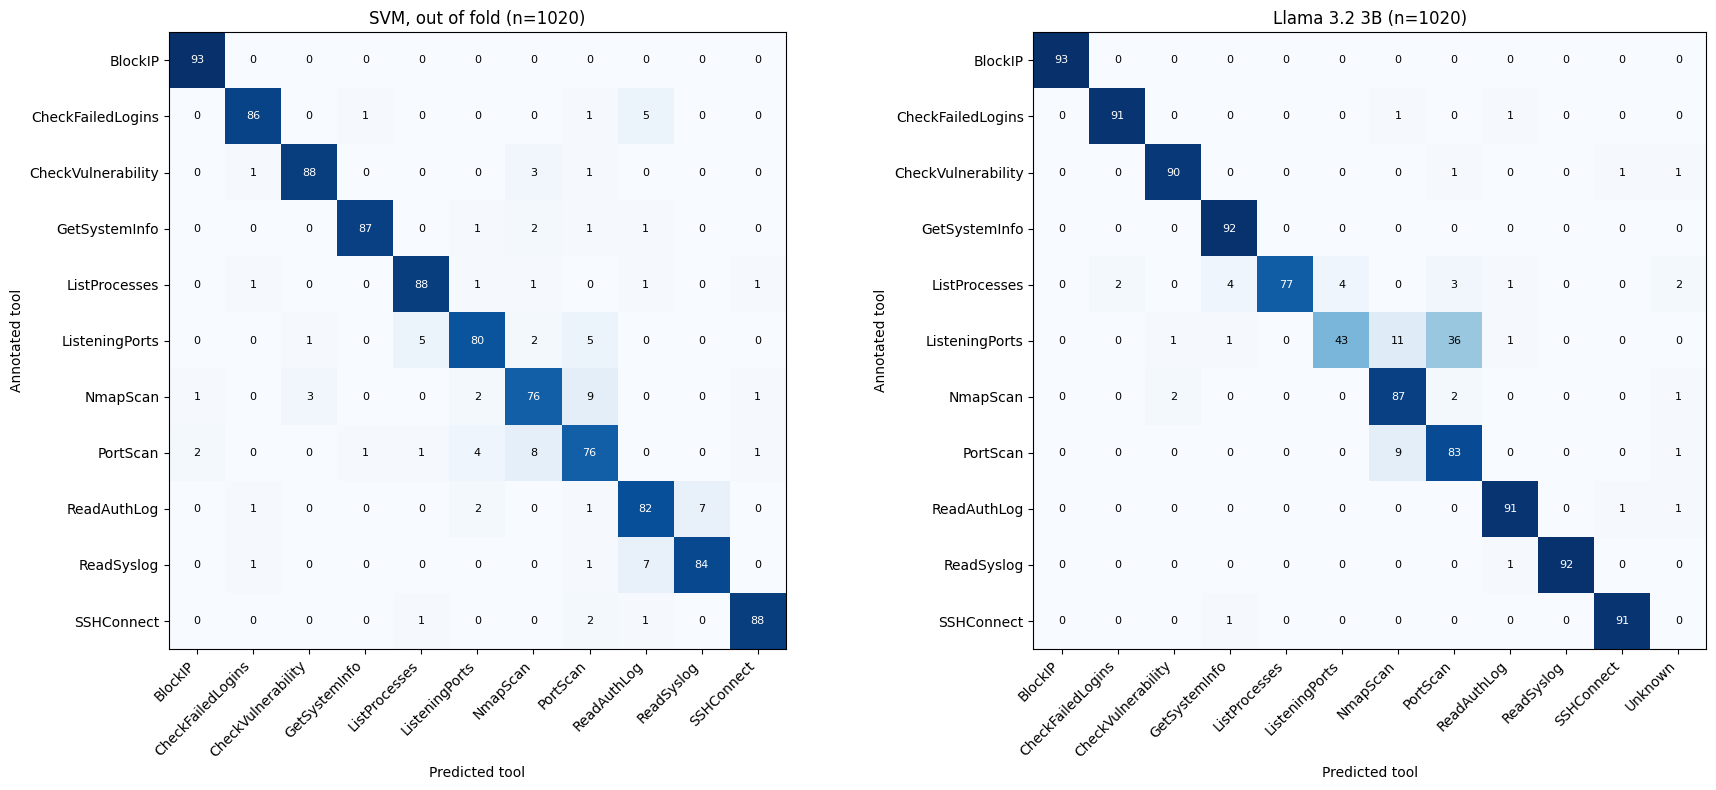

In [7]:
labels = sorted(set(y))
fig, axes = plt.subplots(1, 2, figsize=(18, 8))
for ax, (title, pred) in zip(axes, [("SVM, out of fold", oof["SVM"]), ("Llama 3.2 3B", llama)]):
    lab = labels + (["Unknown"] if "Unknown" in set(pred) else [])
    cm = confusion_matrix(y, pred, labels=lab)[:len(labels)]
    ax.imshow(cm, cmap="Blues")
    ax.set_xticks(range(len(lab))); ax.set_xticklabels(lab, rotation=45, ha="right")
    ax.set_yticks(range(len(labels))); ax.set_yticklabels(labels)
    for i in range(cm.shape[0]):
        for j in range(cm.shape[1]):
            ax.text(j, i, cm[i, j], ha="center", va="center", fontsize=8,
                    color="white" if cm[i, j] > cm.max() / 2 else "black")
    ax.set_xlabel("Predicted tool"); ax.set_ylabel("Annotated tool"); ax.set_title(f"{title} (n={len(y)})")
plt.tight_layout(); plt.savefig("confusion_matrix_C.png", dpi=150); plt.show()

## 7. Add the SVM column and save

In [8]:
C["pred_svm"] = oof["SVM"]
cols = ["prompt", "tool_ground_truth", "tool_predicted", "pred_svm", "source", "row_id"]
C[cols].to_csv("cyber_dataset_C.csv", index=False)
results.to_csv("dataset_c_results.csv", index=False)
print("saved cyber_dataset_C.csv with columns:", cols)

saved cyber_dataset_C.csv with columns: ['prompt', 'tool_ground_truth', 'tool_predicted', 'pred_svm', 'source', 'row_id']
